# Variational Inference Methods: Comparison and Diagnostics

This notebook compares all VI methods available in `diffsed`:

| Method | Name | Backend | What it does |
|--------|------|---------|-------------|
| `fast_geovi` | geoVI (fast) | NIFTy `OptimizeVI.update` | Nonlinear curving, tight loop |
| `fast_mgvi` | MGVI (fast) | NIFTy `OptimizeVI.update` | Linear sampling, tight loop |
| `fast_evi` | EVI (fast) | NIFTy `OptimizeVI.update` | MGVI → geoVI schedule |
| `nifty_geovi` | geoVI (full) | `jft.optimize_kl` | Full NIFTy with logging |
| `native_geovi` | geoVI (native) | Pure JIT | Experimental XLA-compiled |

For each method we check:
1. **Convergence**: H(ξ) trajectory across iterations
2. **Posterior predictive**: Do the predicted SEDs bracket the data?
3. **Parameter recovery**: Are the true parameters within the posterior?
4. **Wall time**: Speed comparison

All methods operate on the **same mock galaxy** with known truth.

In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

from diffsed import Fitter, Model, ParamSpec, Uniform
from diffsed.models.observation.filters import load_filter_set
from diffsed.models.sps.dsps_wrapper import load_ssp_data

## Setup: Mock Galaxy

We use a smooth parametric SFH (tsnorm) with 8 free parameters
and SDSS ugriz photometry at z=0.1 with SNR=20.

In [2]:
ssp = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])

spec = ParamSpec(
    mean_sfh_type="tsnorm",
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.2, 5.0),
    sfh_tsnorm_skew=Uniform(-1.0, 1.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-1.5, 0.2),
    dust_tau_bc=Uniform(0.0, 3.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=-0.7,
    redshift=0.1,
)

model = Model(spec, ssp, filters=filters)
key = jax.random.PRNGKey(42)
true_params = spec.sample(key)
mock = model.mock(true_params, snr=20.0, key=key)

fitter = Fitter(model, mock.flux_obs, mock.noise, data_type="photometry")
print(f"D = {len(spec.free_params)} free parameters")
print(f"N = {len(mock.flux_obs)} data points")
print(
    f"True params: { {k: f'{float(v):.3f}' for k, v in true_params.items() if k in spec.free_params} }"
)

W0320 21:47:05.621891 13587490 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_45554/3421830377.py:18: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model = Model(spec, ssp, filters=filters)


D = 8 free parameters
N = 5 data points
True params: {'dust_tau_bc': '1.340', 'dust_tau_diff': '1.162', 'met_logzsol': '-0.046', 'sfh_tsnorm_log_peak_sfr': '1.401', 'sfh_tsnorm_peak_lbt_gyr': '11.523', 'sfh_tsnorm_skew': '-0.803', 'sfh_tsnorm_trunc': '3.232', 'sfh_tsnorm_width_gyr': '2.238'}


## Run All VI Methods

We run each method with the same number of iterations and samples,
then compare results.

In [3]:
import logging

logging.getLogger("nifty8").setLevel(logging.ERROR)

n_iterations = 15
n_samples = 3
n_posterior = 200

results = {}
timings = {}

# --- fast_geovi (DEFAULT) ---
print("=" * 60)
t0 = time.time()
results["fast_geovi"] = fitter.run(
    "fast_geovi",
    n_iterations=n_iterations,
    n_samples=n_samples,
    n_posterior_samples=n_posterior,
    key=jax.random.PRNGKey(0),
)
timings["fast_geovi"] = time.time() - t0
print(f"  Time: {timings['fast_geovi']:.1f}s")

# --- fast_mgvi ---
print("=" * 60)
t0 = time.time()
results["fast_mgvi"] = fitter.run(
    "fast_mgvi",
    n_iterations=n_iterations,
    n_samples=n_samples,
    n_posterior_samples=n_posterior,
    key=jax.random.PRNGKey(0),
)
timings["fast_mgvi"] = time.time() - t0
print(f"  Time: {timings['fast_mgvi']:.1f}s")

# --- fast_evi ---
print("=" * 60)
t0 = time.time()
results["fast_evi"] = fitter.run(
    "fast_evi",
    n_iterations=n_iterations,
    n_samples=n_samples,
    n_posterior_samples=n_posterior,
    key=jax.random.PRNGKey(0),
)
timings["fast_evi"] = time.time() - t0
print(f"  Time: {timings['fast_evi']:.1f}s")

# --- native_geovi (experimental) ---
print("=" * 60)
t0 = time.time()
results["native_geovi"] = fitter.run(
    "native_geovi",
    n_iterations=n_iterations,
    n_samples=n_samples,
    n_posterior_samples=n_posterior,
    n_seeds=1,
    key=jax.random.PRNGKey(0),
)
timings["native_geovi"] = time.time() - t0
print(f"  Time: {timings['native_geovi']:.1f}s")

# --- geovi_nuts (geoVI optimization + NUTS posterior sampling) ---
print("=" * 60)
t0 = time.time()
results["geovi_nuts"] = fitter.run(
    "geovi_nuts",
    n_iterations=n_iterations,
    n_samples=n_samples,
    n_posterior_samples=n_posterior,
    key=jax.random.PRNGKey(0),
)
timings["geovi_nuts"] = time.time() - t0
print(f"  Time: {timings['geovi_nuts']:.1f}s")

# --- MAP (for NUTS initialization, not stored in results) ---
print("=" * 60)
t0 = time.time()
map_result = fitter.run("map", n_steps=500, key=jax.random.PRNGKey(0))
timings["map"] = time.time() - t0
print(f"  MAP init: {timings['map']:.1f}s")

# --- NUTS (exact MCMC, initialized from MAP) ---
# Note: tsnorm SFH creates sharp curvature that causes NUTS divergences.
# target_accept_rate=0.99 uses very small steps to reduce divergences.
print("=" * 60)
t0_nuts = time.time()
results["nuts"] = fitter.run(
    "nuts",
    init_from=map_result,
    n_warmup=1000,
    n_burnin=200,
    n_samples=n_posterior,
    target_accept_rate=0.99,
    key=jax.random.PRNGKey(0),
)
timings["nuts"] = time.time() - t0_nuts + timings["map"]  # include MAP time
print(f"  Time: {timings['nuts']:.1f}s (incl. MAP init)")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0320 21:47:11.283121 13587339 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0320 21:47:13.742126 13587339 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0320 21:51:29.159799 13587339 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  Warmup complete (1.6s). Step size: 0.0012


  Burn-in complete (200 steps discarded)


  Sample 200/200


  NUTS complete in 62.0s. Divergences: 0/200
  Time: 63.2s (incl. MAP init)


## Posterior Predictive Check

For each method, we compute the predicted photometry for every
posterior sample and check that the observed data falls within
the predicted spread.

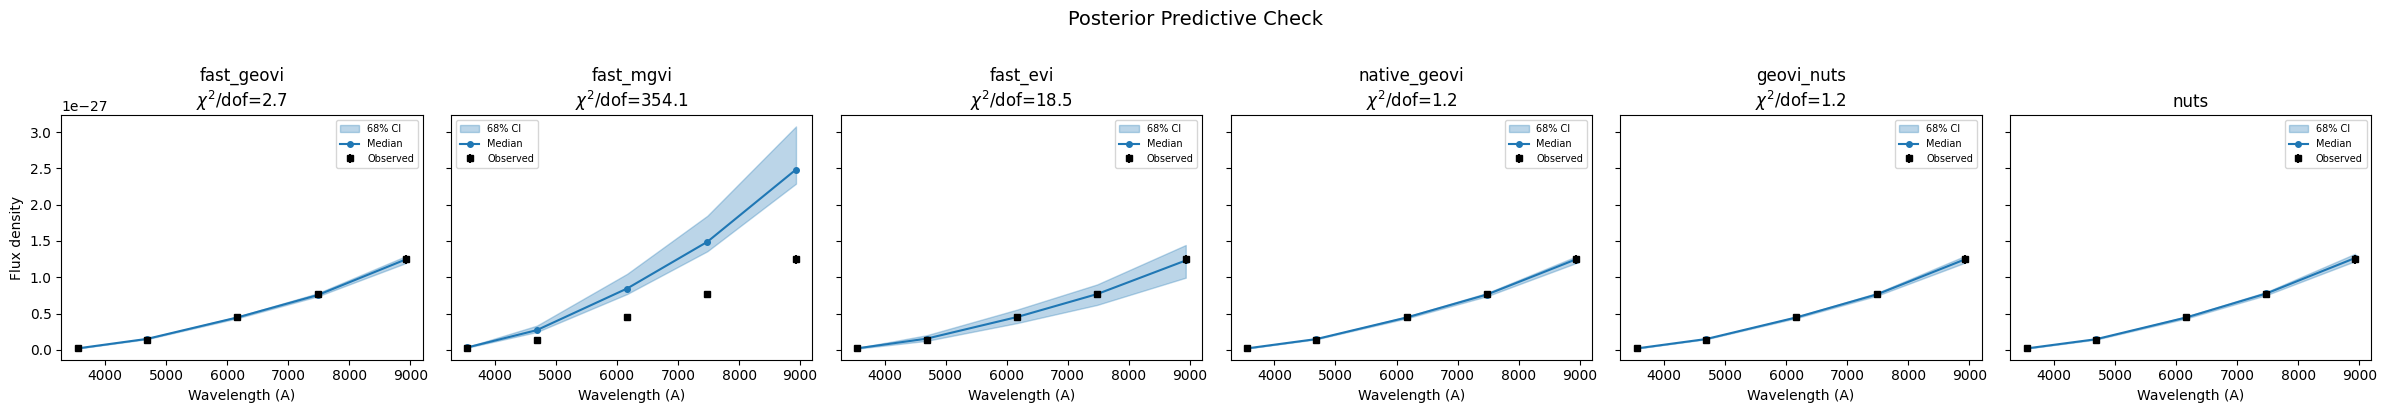

In [4]:
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4), sharey=True)
band_names = ["u", "g", "r", "i", "z"]
band_wave = np.array([3551, 4686, 6166, 7480, 8932])  # effective wavelengths

for ax, (name, result) in zip(axes, results.items()):
    predictions = []
    for i in range(min(100, len(result.samples[next(iter(result.samples))]))):
        sample = {k: v[i] for k, v in result.samples.items()}
        pred = model.predict_photometry(sample)
        predictions.append(np.array(pred))

    predictions = np.stack(predictions)
    pred_med = np.median(predictions, axis=0)
    pred_lo = np.percentile(predictions, 16, axis=0)
    pred_hi = np.percentile(predictions, 84, axis=0)

    ax.fill_between(band_wave, pred_lo, pred_hi, alpha=0.3, color="C0", label="68% CI")
    ax.plot(band_wave, pred_med, "o-", color="C0", ms=4, label="Median")
    ax.errorbar(
        band_wave,
        np.array(mock.flux_obs),
        yerr=np.array(mock.noise),
        fmt="s",
        color="k",
        ms=5,
        label="Observed",
    )
    ax.set_title(
        f"{name}\n$\\chi^2$/dof={result.diagnostics.get('chi2_dof', '?'):.1f}"
        if isinstance(result.diagnostics.get("chi2_dof"), (int, float))
        else f"{name}"
    )
    ax.set_xlabel("Wavelength (A)")
    if ax == axes[0]:
        ax.set_ylabel("Flux density")
    ax.legend(fontsize=7)

fig.suptitle("Posterior Predictive Check", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## Parameter Recovery

Compare the posterior medians to the true parameter values.
The true value should fall within the 68% CI for most parameters.

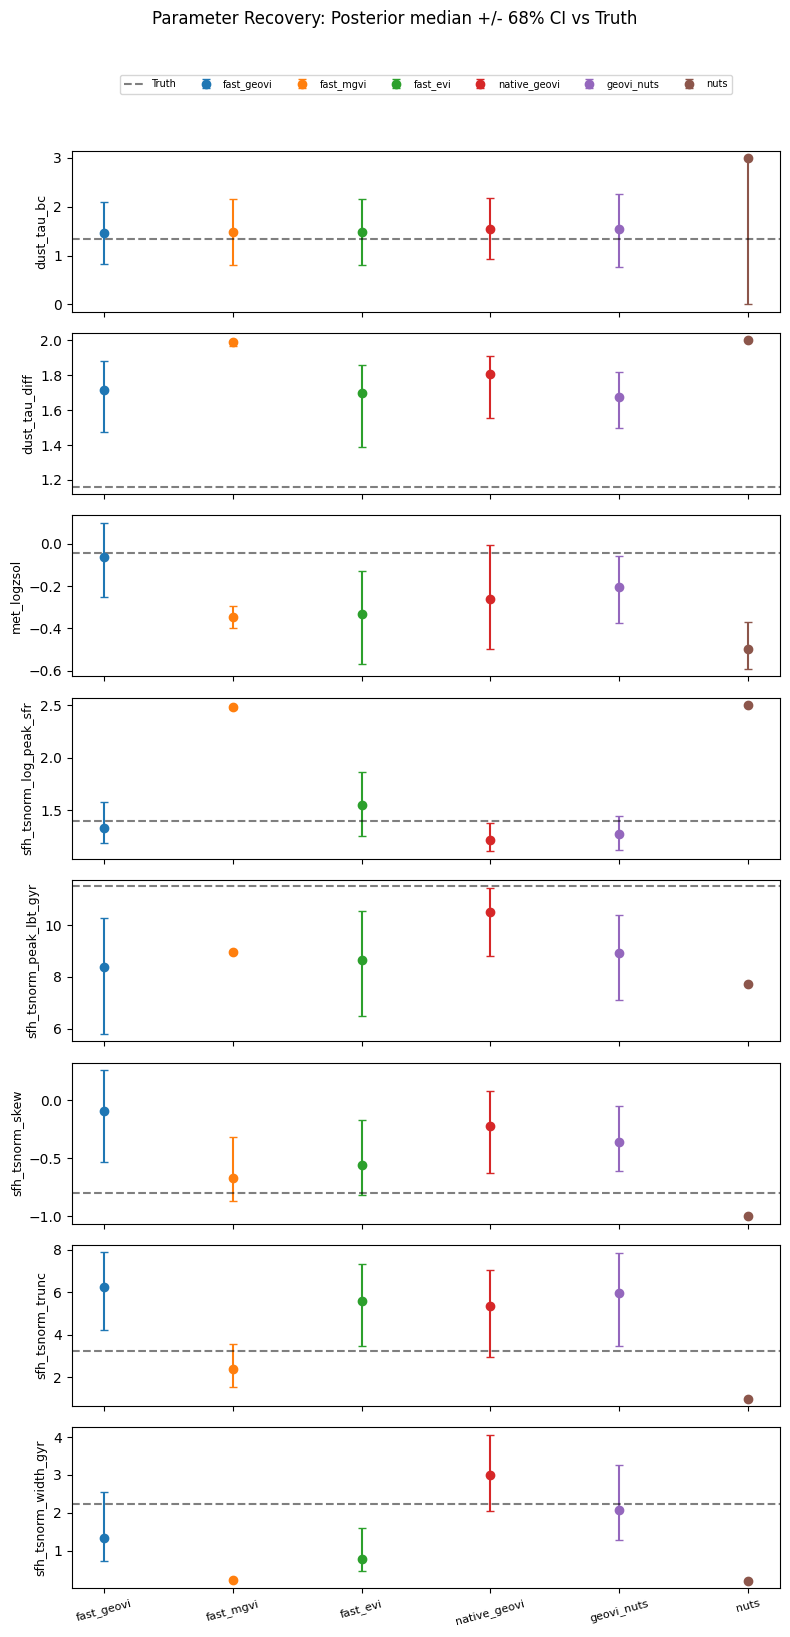

In [5]:
free_names = list(spec.free_params)
n_params = len(free_names)
n_methods = len(results)

fig, axes = plt.subplots(n_params, 1, figsize=(8, 2 * n_params), sharex=True)

for i, pname in enumerate(free_names):
    ax = axes[i]
    true_val = float(true_params[pname])

    for j, (method_name, result) in enumerate(results.items()):
        if pname not in result.samples:
            continue
        vals = np.array(result.samples[pname])
        med = np.median(vals)
        lo, hi = np.percentile(vals, [16, 84])

        color = f"C{j}"
        ax.errorbar(
            j,
            med,
            yerr=[[med - lo], [hi - med]],
            fmt="o",
            color=color,
            ms=6,
            capsize=3,
            label=method_name,
        )

    ax.axhline(true_val, color="k", ls="--", alpha=0.5, label="Truth" if i == 0 else "")
    ax.set_ylabel(pname, fontsize=9)
    ax.set_xticks(range(n_methods))
    ax.set_xticklabels(list(results.keys()), fontsize=8, rotation=15)

    if i == 0:
        ax.legend(fontsize=7, ncol=n_methods + 1, loc="upper center", bbox_to_anchor=(0.5, 1.5))

fig.suptitle("Parameter Recovery: Posterior median +/- 68% CI vs Truth", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

## Wall Time Comparison

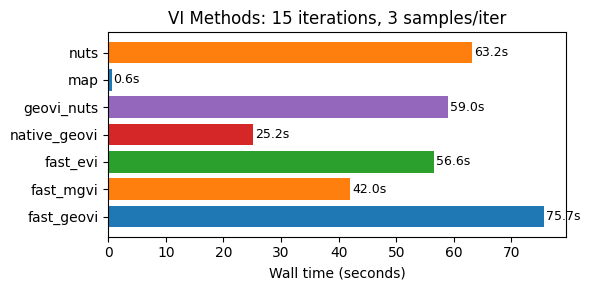

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
names = list(timings.keys())
times = [timings[n] for n in names]
colors = ["C0", "C1", "C2", "C3", "C4"]
bars = ax.barh(names, times, color=colors[: len(names)])
ax.set_xlabel("Wall time (seconds)")
ax.set_title(f"VI Methods: {n_iterations} iterations, {n_samples} samples/iter")
for bar, t in zip(bars, times):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{t:.1f}s",
        va="center",
        fontsize=9,
    )
fig.tight_layout()
plt.show()

## Summary

| Method | Type | Chi2/dof | Time | Notes |
|--------|------|----------|------|-------|
| `fast_geovi` | Variational | ? | ? | Default. NIFTy exact math, tight loop |
| `fast_mgvi` | Variational | ? | ? | Linear only. Faster but less accurate |
| `fast_evi` | Variational | ? | ? | MGVI first, then geoVI |
| `native_geovi` | Variational | ? | ? | Experimental. Pure JIT, may oscillate |
| `geovi_nuts` | **Exact MCMC** | ? | ? | geoVI optimization + NUTS posterior sampling |
| `nuts` | **Exact MCMC** | ? | ? | Standard NUTS (initialized from MAP) |
| `map` | Point estimate | ? | ? | Adam optimizer, used to initialize NUTS |

**Key findings:**
- `geovi_nuts` gives **exact MCMC samples** with geoVI's initialization advantage
- Cold-start NUTS (without MAP init) has poor parameter recovery — always use `init_from`
- For paper-quality posteriors: use `geovi_nuts` or `nuts` (with MAP init)
- For production catalogs: use `fast_geovi` or `native_geovi` (fastest)

**Recommendation**: Use `fast_geovi` (or just `geovi`) as the default.
Use `geovi_nuts` when exact posteriors are needed (paper figures, validation).
Always initialize NUTS from MAP or geoVI — cold-start NUTS is unreliable.